In [1]:
import sys, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.dates as mdates
import seaborn as sns
import sys
sys.path.append("..")   # so the notebook can find the fetchers/ module
import pandas as pd
import matplotlib.pyplot as plt
from src.fetch_binance_hourly import fetch_binance, EXCHANGE_CONSTANTS

# ── PARAMETERS — edit these ──────────────────────────────────────────────────
ASSET       = "BTC"
START_DATE  = "2020-01-01T00:00:00Z"
END_DATE    = "2026-01-01T00:00:00Z"
TIMEFRAME   = "1h"
SPREAD_BPS  = 2.0    # 2 bps for BTC/ETH, use 5–10 for altcoins
OUTPUT_PATH = f"./data/hourly/btc/binance_{ASSET}_{START_DATE[:10]}_{END_DATE[:10]}.parquet"
COLORS = plt.rcParams['axes.prop_cycle'].by_key()['color']

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.35,
    'font.size': 10,
})

## Binance

In [ ]:
df = fetch_binance(
    asset      = ASSET,
    start_date = START_DATE,
    end_date   = END_DATE,
    timeframe  = TIMEFRAME,
    spread_bps = SPREAD_BPS,
)


Fetching Binance data — BTC | 2020-01-01T00:00:00Z → 2026-01-01T00:00:00Z
Spread assumption: ±2.0 bps around close

[1/4] Perp OHLCV...
  [BTC/USDT:USDT] up to 2020-02-11 15:00:00+00:00  |  rows: 1000
  [BTC/USDT:USDT] up to 2020-03-24 07:00:00+00:00  |  rows: 2000
  [BTC/USDT:USDT] up to 2020-05-04 23:00:00+00:00  |  rows: 3000
  [BTC/USDT:USDT] up to 2020-06-15 15:00:00+00:00  |  rows: 4000
  [BTC/USDT:USDT] up to 2020-07-27 07:00:00+00:00  |  rows: 5000
  [BTC/USDT:USDT] up to 2020-09-06 23:00:00+00:00  |  rows: 6000
  [BTC/USDT:USDT] up to 2020-10-18 15:00:00+00:00  |  rows: 7000
  [BTC/USDT:USDT] up to 2020-11-29 07:00:00+00:00  |  rows: 8000
  [BTC/USDT:USDT] up to 2021-01-09 23:00:00+00:00  |  rows: 9000
  [BTC/USDT:USDT] up to 2021-02-20 15:00:00+00:00  |  rows: 10000
  [BTC/USDT:USDT] up to 2021-04-03 07:00:00+00:00  |  rows: 11000
  [BTC/USDT:USDT] up to 2021-05-14 23:00:00+00:00  |  rows: 12000
  [BTC/USDT:USDT] up to 2021-06-25 15:00:00+00:00  |  rows: 13000
  [BTC/USDT:US

In [9]:
df

,mark_price_binance,best_bid_binance,best_ask_binance,spot_best_bid_binance,spot_best_ask_binance,funding_rate_raw_binance
timestamp,,,,,,
2020-01-01 00:00:00+00:00,7171.55,7170.115690,7172.984310,7175.584596,7178.455404,-0.000124
2020-01-01 01:00:00+00:00,7210.24,7208.797952,7211.682048,7214.826746,7217.713254,-0.000124
2020-01-01 02:00:00+00:00,7237.99,7236.542402,7239.437598,7241.401430,7244.298570,-0.000124
2020-01-01 03:00:00+00:00,7221.65,7220.205670,7223.094330,7223.564998,7226.455002,-0.000124
2020-01-01 04:00:00+00:00,7213.86,7212.417228,7215.302772,7215.826546,7218.713454,-0.000124


In [10]:
df_binance.shape

(52609, 6)

In [ ]:
df.index = pd.to_datetime(df.index)
df.to_parquet(OUTPUT_PATH)

In [7]:
for coin in COINS:
    outfile = f"./data/{coin.upper()}/binance_{coin.upper()}_{START_DATE[:10]}_{END_DATE[:10]}.parquet"

    if not os.path.exists(outfile):
        print(f"⏭️  {coin} — file not found, skipping")
        continue

    df = pd.read_parquet(outfile)

    # Binance funding_rate_raw is the full 8h settlement rate
    # → divide by 8 to get hourly, already USD per USD notional (linear USDT contracts)
    df["funding_rate_normalized_binance"] = df["funding_rate_raw_binance"] / 8

    df = df.drop(columns=[
        col for col in ["funding_rate_raw_binance"]
        if col in df.columns
    ])
    print(df.columns)
    df.to_parquet(outfile)
    print(f"✅ {coin} — saved with funding_rate_normalized_binance ({df['funding_rate_normalized_binance'].notna().sum()} non-NaN rows)")


Index(['mark_price_binance', 'best_bid_binance', 'best_ask_binance',
       'spot_best_bid_binance', 'spot_best_ask_binance',
       'funding_rate_normalized_binance'],
      dtype='str')
✅ BTC — saved with funding_rate_normalized_binance (54025 non-NaN rows)
Index(['mark_price_binance', 'best_bid_binance', 'best_ask_binance',
       'spot_best_bid_binance', 'spot_best_ask_binance',
       'funding_rate_normalized_binance'],
      dtype='str')
✅ ETH — saved with funding_rate_normalized_binance (54025 non-NaN rows)
Index(['mark_price_binance', 'best_bid_binance', 'best_ask_binance',
       'spot_best_bid_binance', 'spot_best_ask_binance',
       'funding_rate_normalized_binance'],
      dtype='str')
✅ SOL — saved with funding_rate_normalized_binance (47841 non-NaN rows)
Index(['mark_price_binance', 'best_bid_binance', 'best_ask_binance',
       'spot_best_bid_binance', 'spot_best_ask_binance',
       'funding_rate_normalized_binance'],
      dtype='str')
✅ XRP — saved with funding_rate_

### Quick analysis

In [15]:
df['mid_price'] = (df['best_bid_binance'] + df['best_ask_binance']) / 2
df['spot_mid_price'] = df['spot_best_bid_binance'] + (df['spot_best_ask_binance'] - df['spot_best_bid_binance']) / 2

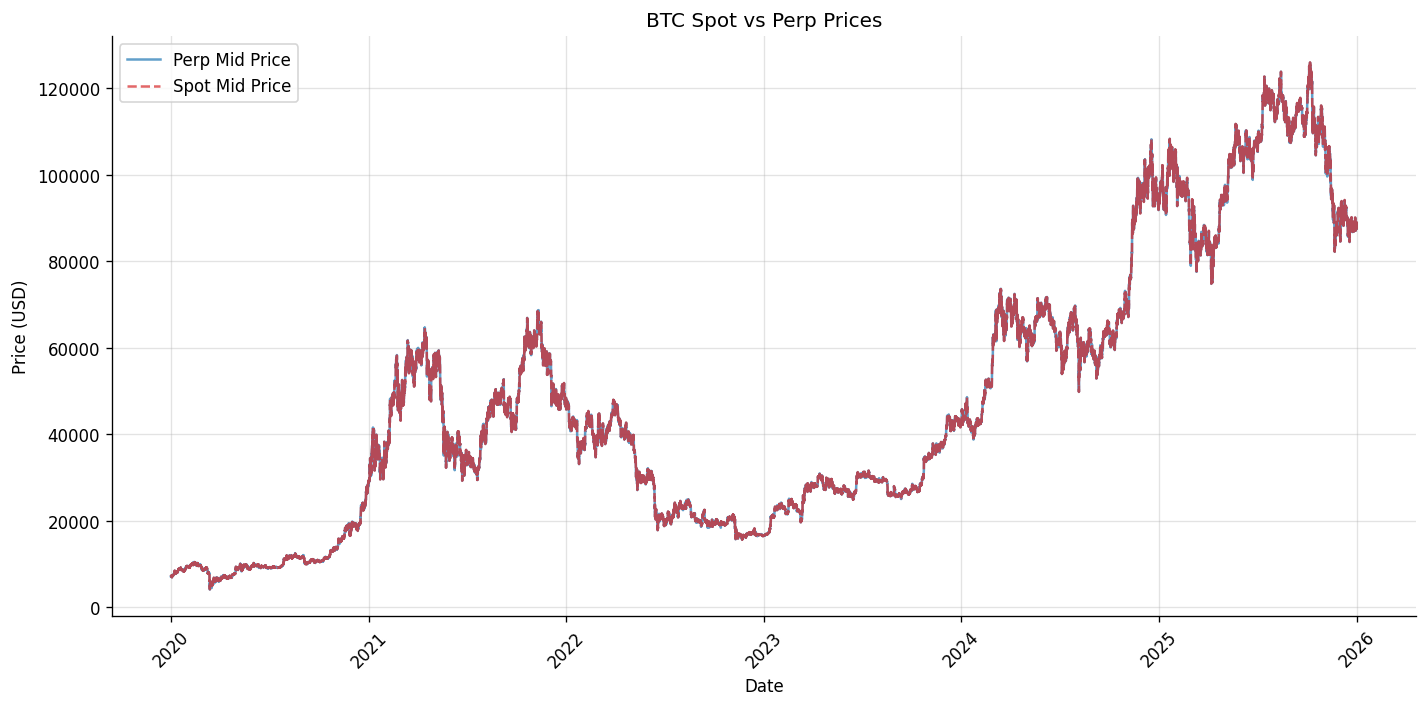

In [16]:
#plot best bid/ask for both spot and perp
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(df.index, df['mid_price'], label='Perp Mid Price', color=COLORS[0], alpha=0.7)
ax.plot(df.index, df['spot_mid_price'], label='Spot Mid Price', color   =COLORS[3], alpha=0.7, linestyle='--')
ax.set_title(f"{ASSET} Spot vs Perp Prices")
ax.set_xlabel("Date")
ax.set_ylabel("Price (USD)")
ax.legend()
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(rotation=45)
plt.tight_layout()

## Deribit

In [ ]:
# Fetch
deribit_funding = fetch_deribit_funding_df(
    asset      = "BTC",
    start_date = "2020-01-01",
    end_date   = "2026-01-01",
)

# Inspect
print(deribit_funding.head(3))
print(f"Shape: {deribit_funding.shape}")
print(f"NaNs : {deribit_funding.isna().sum().item()}")


In [3]:

from src.fetch_deribit_hourly import fetch_deribit, DERIBIT_SYMBOLS
import os

# ── CONFIG ───────────────────────────────────────────────────────────────────
COINS      = list(DERIBIT_SYMBOLS.keys())   # ["BTC", "ETH", "SOL", "XRP", "BNB", "AVAX", "DOGE"]
START_DATE = "2020-01-01T00:00:00Z"
END_DATE   = "2026-03-01T00:00:00Z"
TIMEFRAME  = "1h"
DATA_DIR   = "./data"

# ── FETCH & SAVE LOOP ────────────────────────────────────────────────────────
failed = []

for coin in COINS:
    outdir  = os.path.join(DATA_DIR, coin.upper())
    outfile = os.path.join(outdir, f"deribit_{coin.upper()}_{START_DATE[:10]}_{END_DATE[:10]}.parquet")

    # Skip if already fetched — remove this block to force re-fetch
    if os.path.exists(outfile):
        print(f"⏭️  {coin} — already exists, skipping ({outfile})")
        continue

    try:
        df = fetch_deribit(
            asset      = coin,
            start_date = START_DATE,
            end_date   = END_DATE,
            timeframe  = TIMEFRAME,
        )
        os.makedirs(outdir, exist_ok=True)
        df.to_parquet(outfile)
        print(f"💾 Saved {coin} → {outfile}  ({len(df)} rows)\n")

    except Exception as e:
        print(f"❌ {coin} failed: {e}\n")
        failed.append((coin, str(e)))

# ── SUMMARY ──────────────────────────────────────────────────────────────────
print(f"\n{'='*55}")
print(f"Done. {len(COINS) - len(failed)}/{len(COINS)} coins fetched successfully.")
if failed:
    print("Failed:")
    for coin, err in failed:
        print(f"  {coin}: {err}")




Fetching Deribit — BTC (BTC-PERPETUAL)
Range     : 2020-01-01T00:00:00Z → 2026-03-01T00:00:00Z
Spread    : ±1.5 bps  |  Inverse: True

[1/2] Perp OHLCV...
  Fetching OHLCV for BTC-PERPETUAL...
    2025-08-04 16:00:00+00:00 → 2026-03-01 00:00:00+00:00 | rows: 5001 | total: 5001
    2025-01-08 07:00:00+00:00 → 2025-08-04 15:00:00+00:00 | rows: 5001 | total: 10002
    2024-06-13 22:00:00+00:00 → 2025-01-08 06:00:00+00:00 | rows: 5001 | total: 15003
    2023-11-18 13:00:00+00:00 → 2024-06-13 21:00:00+00:00 | rows: 5001 | total: 20004
    2023-04-24 04:00:00+00:00 → 2023-11-18 12:00:00+00:00 | rows: 5001 | total: 25005
    2022-09-27 19:00:00+00:00 → 2023-04-24 03:00:00+00:00 | rows: 5001 | total: 30006
    2022-03-03 10:00:00+00:00 → 2022-09-27 18:00:00+00:00 | rows: 5001 | total: 35007
    2021-08-07 01:00:00+00:00 → 2022-03-03 09:00:00+00:00 | rows: 5001 | total: 40008
    2021-01-10 16:00:00+00:00 → 2021-08-07 00:00:00+00:00 | rows: 5001 | total: 45009
    2020-06-16 07:00:00+00:00 → 2

In [5]:
import os

COINS      = list(DERIBIT_SYMBOLS.keys())
START_DATE = "2020-01-01T00:00:00Z"
END_DATE   = "2026-03-01T00:00:00Z"

print(f"{'Coin':<6} {'First price':<28} {'First funding':<28} {'NaN prices':>10} {'NaN funding':>12}")
print("-" * 90)

for coin in COINS:
    outfile = f"./data/{coin.upper()}/deribit_{coin.upper()}_{START_DATE[:10]}_{END_DATE[:10]}.parquet"
    if not os.path.exists(outfile):
        print(f"{coin:<6} — file not found")
        continue

    df = pd.read_parquet(outfile)

    first_price   = df["mark_price_deribit"].first_valid_index()
    first_funding = df["funding_rate_raw_deribit"].first_valid_index()
    nan_price     = df["mark_price_deribit"].isna().sum()
    nan_funding   = df["funding_rate_raw_deribit"].isna().sum()

    print(f"{coin:<6} {str(first_price):<28} {str(first_funding):<28} {nan_price:>10} {nan_funding:>12}")


Coin   First price                  First funding                NaN prices  NaN funding
------------------------------------------------------------------------------------------
BTC    2020-01-01 00:00:00+00:00    2020-01-01 01:00:00+00:00             0            3
ETH    2020-01-01 00:00:00+00:00    2020-01-01 01:00:00+00:00             0            3
SOL    2022-03-15 13:00:00+00:00    2022-03-16 09:00:00+00:00         19309        19329
XRP    2022-03-16 13:00:00+00:00    2022-03-17 09:00:00+00:00         19333        19353
BNB    2024-10-01 11:00:00+00:00    2024-09-18 09:00:00+00:00         41651        41337
AVAX   2022-03-17 13:00:00+00:00    2022-03-18 09:00:00+00:00         19357        19377
DOGE   2022-04-28 14:00:00+00:00    2022-04-29 09:00:00+00:00         20366        20385


In [6]:
for coin in COINS:
    outfile = f"./data/{coin.upper()}/deribit_{coin.upper()}_{START_DATE[:10]}_{END_DATE[:10]}.parquet"

    if not os.path.exists(outfile):
        print(f"⏭️  {coin} — file not found, skipping")
        continue

    df = pd.read_parquet(outfile)

    # funding_rate_usd is already hourly for Deribit (interest_1h × mark_price for inverse,
    # interest_1h as-is for linear) — rename directly, no further division needed
    df["funding_rate_normalized_deribit"] = df["funding_rate_usd_deribit"]

    # Drop intermediate columns
    df = df.drop(columns=[
        col for col in ["funding_rate_raw_deribit", "funding_rate_usd_deribit"]
        if col in df.columns
    ])
    print(df.head())
    df.to_parquet(outfile)
    print(f"✅ {coin} — saved with funding_rate_normalized_deribit ({df['funding_rate_normalized_deribit'].notna().sum()} non-NaN rows)")


                           mark_price_deribit  best_bid_deribit  \
timestamp                                                         
2020-01-01 00:00:00+00:00              7157.5       7156.426375   
2020-01-01 01:00:00+00:00              7200.0       7198.920000   
2020-01-01 02:00:00+00:00              7222.0       7220.916700   
2020-01-01 03:00:00+00:00              7206.5       7205.419025   
2020-01-01 04:00:00+00:00              7198.5       7197.420225   

                           best_ask_deribit  funding_rate_normalized_deribit  
timestamp                                                                     
2020-01-01 00:00:00+00:00       7158.573625                              NaN  
2020-01-01 01:00:00+00:00       7201.080000                         0.006227  
2020-01-01 02:00:00+00:00       7223.083300                         0.070139  
2020-01-01 03:00:00+00:00       7207.580975                         0.020689  
2020-01-01 04:00:00+00:00       7199.579775             

## Compute overall best bid and ask

In [ ]:
import pandas as pd
import re

def compute_best_prices(df: pd.DataFrame) -> pd.DataFrame:
    """
    Scans all columns matching best_bid_{exchange} / best_ask_{exchange} /
    spot_best_bid_{exchange} / spot_best_ask_{exchange} and computes
    the best executable prices across all exchanges.

    Returns 4 new columns added to a copy of df:

        perp_max_bid  — highest perp bid across exchanges  (best short entry)
        perp_min_ask  — lowest  perp ask across exchanges  (best long  entry)
        spot_max_bid  — highest spot bid across exchanges  (best spot exit / short spot entry)
        spot_min_ask  — lowest  spot ask across exchanges  (best spot entry / long spot)

    Derived spreads you can compute afterwards
    ------------------------------------------
    Contango leg   (short perp, long spot):
        executable_spread = perp_max_bid - spot_min_ask
        → positive = you short perp above where you buy spot → collect the gap

    Backwardation leg  (long perp, short spot):
        executable_spread = spot_max_bid - perp_min_ask
        → positive = you sell spot above where you buy perp → collect the gap

    Parameters
    ----------
    df : pd.DataFrame
        Wide-format dataframe with columns like best_bid_binance,
        spot_best_ask_bybit, etc. Any number of exchanges supported.

    Returns
    -------
    pd.DataFrame — original df with 4 new columns appended.
    """

    # ── Auto-detect columns by pattern ───────────────────────────────────────
    perp_bid_cols = [c for c in df.columns if re.fullmatch(r"best_bid_\w+", c)]
    perp_ask_cols = [c for c in df.columns if re.fullmatch(r"best_ask_\w+", c)]
    spot_bid_cols = [c for c in df.columns if re.fullmatch(r"spot_best_bid_\w+", c)]
    spot_ask_cols = [c for c in df.columns if re.fullmatch(r"spot_best_ask_\w+", c)]

    # ── Validate ──────────────────────────────────────────────────────────────
    missing = {
        "best_bid_{exchange}":      perp_bid_cols,
        "best_ask_{exchange}":      perp_ask_cols,
        "spot_best_bid_{exchange}": spot_bid_cols,
        "spot_best_ask_{exchange}": spot_ask_cols,
    }
    for pattern, found in missing.items():
        if not found:
            raise ValueError(f"No columns matching '{pattern}' found in df.")

    detected = {
        "perp bid columns": perp_bid_cols,
        "perp ask columns": perp_ask_cols,
        "spot bid columns": spot_bid_cols,
        "spot ask columns": spot_ask_cols,
    }
    for label, cols in detected.items():
        print(f"  Detected {label}: {cols}")

    # ── Compute ───────────────────────────────────────────────────────────────
    out = df.copy()

    # Contango leg   (short perp, long spot):
    #     executable_spread = perp_max_bid - spot_min_ask
    out["perp_max_bid"] = df[perp_bid_cols].max(axis=1)   # best short perp entry
    out["spot_min_ask"] = df[spot_ask_cols].min(axis=1)   # best long  spot entry
    
    # Backwardation leg  (long perp, short spot):
    #     executable_spread = spot_max_bid - perp_min_ask
    out["perp_min_ask"] = df[perp_ask_cols].min(axis=1)   # best long  perp entry
    out["spot_max_bid"] = df[spot_bid_cols].max(axis=1)   # best short spot entry

    return out

def plot_spread_regimes(
    df: pd.DataFrame,
    asset: str = "BTC",
    figsize: tuple = (14, 10),
    rolling_window: int = 24,       # hours, for smoothing
    bps_clip: float = 100.0,        # clip extreme outliers for readability
) -> None:
    """
    Visualises contango and backwardation spreads across exchanges over time.

    Expects df to already contain:
        spread_contango_bps, spread_backwardation_bps
    (computed via compute_best_prices + the bps normalization step)

    Panels
    ------
    1. Raw spreads — both series on same axis, zero line, shaded regions
    2. Rolling mean of both spreads — smoothed trend
    3. Regime classification — color-coded bars:
          pure contango       : contango > 0 AND backwardation < 0
          pure backwardation  : contango < 0 AND backwardation > 0
          both positive       : cross-exchange dislocation (most interesting)
          both negative       : arbitrage fully closed / inverted
    4. Spread divergence = spread_contango_bps + spread_backwardation_bps
          Near zero  → symmetric, as expected in unified market
          Non-zero   → cross-exchange fragmentation
    """

    required = ["spread_contango_bps", "spread_backwardation_bps"]
    for col in required:
        if col not in df.columns:
            raise ValueError(f"Missing column '{col}'. Run compute_best_prices() first.")

    # ── Clip outliers ─────────────────────────────────────────────────────────
    c  = df["spread_contango_bps"].clip(-bps_clip, bps_clip)
    b  = df["spread_backwardation_bps"].clip(-bps_clip, bps_clip)
    idx = df.index

    # ── Rolling means ─────────────────────────────────────────────────────────
    c_roll = c.rolling(rolling_window, min_periods=1).mean()
    b_roll = b.rolling(rolling_window, min_periods=1).mean()

    # ── Regime classification ─────────────────────────────────────────────────
    # 0 = pure contango | 1 = pure backwardation | 2 = both positive | 3 = both negative
    conditions = [
        (c > 0) & (b < 0),   # pure contango
        (c < 0) & (b > 0),   # pure backwardation
        (c > 0) & (b > 0),   # both positive  ← cross-exchange dislocation
        (c < 0) & (b < 0),   # both negative  ← arb closed / inverted
    ]
    regime_labels  = ["Pure contango", "Pure backwardation", "Both positive ⚡", "Both negative"]
    regime_colors  = ["#2196F3", "#FF5722", "#9C27B0", "#607D8B"]
    regime_series  = pd.Series(3, index=idx)  # default: both negative
    for i, cond in enumerate(conditions):
        regime_series[cond] = i

    # ── Divergence ────────────────────────────────────────────────────────────
    divergence = c + b   # should be ~0 in a unified market

    # ── Plot ──────────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(4, 1, figsize=figsize, sharex=True)
    fig.suptitle(
        f"{asset} — Cross-Exchange Spread Analysis\n"
        f"Contango: perp_max_bid − spot_min_ask  |  "
        f"Backwardation: spot_max_bid − perp_min_ask",
        fontsize=11, fontweight="bold"
    )

    # Panel 1 — Raw spreads
    ax = axes[0]
    ax.plot(idx, c, color="#2196F3", linewidth=0.6, alpha=0.8, label="Spread contango (bps)")
    ax.plot(idx, b, color="#FF5722", linewidth=0.6, alpha=0.8, label="Spread backwardation (bps)")
    ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
    ax.fill_between(idx, c, 0, where=(c > 0), alpha=0.12, color="#2196F3")
    ax.fill_between(idx, b, 0, where=(b > 0), alpha=0.12, color="#FF5722")
    ax.set_ylabel("bps")
    ax.set_title("Raw spreads (clipped)", fontsize=9)
    ax.legend(fontsize=8, loc="upper right")

    # Panel 2 — Rolling means
    ax = axes[1]
    ax.plot(idx, c_roll, color="#2196F3", linewidth=1.2, label=f"Contango {rolling_window}h MA")
    ax.plot(idx, b_roll, color="#FF5722", linewidth=1.2, label=f"Backwardation {rolling_window}h MA")
    ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
    ax.set_ylabel("bps")
    ax.set_title(f"Rolling {rolling_window}h mean", fontsize=9)
    ax.legend(fontsize=8, loc="upper right")

    # Panel 3 — Regime bars
    ax = axes[2]
    for i, (label, color) in enumerate(zip(regime_labels, regime_colors)):
        mask = regime_series == i
        if mask.any():
            ax.fill_between(idx, 0, 1,
                            where=mask,
                            transform=ax.get_xaxis_transform(),
                            alpha=0.6, color=color, label=label)
    ax.set_yticks([])
    ax.set_title("Regime classification", fontsize=9)
    ax.legend(fontsize=8, loc="upper right", ncol=2)

    # Panel 4 — Divergence
    ax = axes[3]
    ax.plot(idx, divergence, color="#4CAF50", linewidth=0.7, alpha=0.9)
    ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
    ax.fill_between(idx, divergence, 0, where=(divergence > 0), alpha=0.2, color="#4CAF50")
    ax.fill_between(idx, divergence, 0, where=(divergence < 0), alpha=0.2, color="#F44336")
    ax.set_ylabel("bps")
    ax.set_xlabel("Timestamp (UTC)")
    ax.set_title(
        "Spread divergence = contango + backwardation  (≈0 in unified market, ≠0 = fragmentation)",
        fontsize=9
    )

    # ── Regime frequency annotation ───────────────────────────────────────────
    total = len(regime_series)
    freq_text = "  |  ".join([
        f"{label}: {(regime_series == i).sum() / total:.1%}"
        for i, label in enumerate(regime_labels)
    ])
    fig.text(0.5, 0.01, freq_text, ha="center", fontsize=8, color="gray")

    plt.tight_layout(rect=[0, 0.03, 1, 1])
    plt.show()

    # ── Print summary ─────────────────────────────────────────────────────────
    print(f"\n{'='*55}")
    print(f"Regime breakdown — {asset}")
    print(f"{'='*55}")
    for i, label in enumerate(regime_labels):
        pct = (regime_series == i).sum() / total
        print(f"  {label:<28} {pct:.1%}")
    print(f"\n  Divergence mean : {divergence.mean():.2f} bps")
    print(f"  Divergence std  : {divergence.std():.2f} bps")
    print(f"  Both-positive periods (cross-exchange arb): "
          f"{(regime_series == 2).sum()} rows "
          f"({(regime_series == 2).sum() / total:.1%})")

plot_spread_regimes(df, asset=ASSET, rolling_window=24, bps_clip=50.0)
